<a href="https://colab.research.google.com/github/HKozuka/IDX-Exchange-Data-Science/blob/main/02_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IDX Exchange Internship - Data Preprocessing**

## Setup

In [271]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [272]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Show all columns
pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/drive/MyDrive/IDX Exchange Data Science Internship/Google Colab Notebooks/filtered_residential_single_family_listings.csv')

df.head()

/tmp/ipykernel_1513/2699690955.py:12: DtypeWarning: Columns (2,45,78,79,80,81,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/IDX Exchange Data Science Internship/Google Colab Notebooks/filtered_residential_single_family_listings.csv')


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,Michael,Darwich,32.659315,-117.096922,2811 C Avenue,Residential,1974.0,759900.0,33,Berkshire Hathaway HomeServices California Pro...,FOSTER HAMILTON Real Estate,NaN,Michael Darwich,NaN,NaN,SAND-606727,Charles,Street,NaN,NaN,NaN,522107581,91950 - National City,NaN,San Diego,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,NaN,National City,SanDiego,2023.0,Item1,2811.0,210014555,4.0,National City,2.0,NaN,NaN,4.0,2024-01-05,NaN,NaN,2021-06-30,2021-03-08,NaN,NaN,CA,NaN,NaN,False,2.0,NaN,Two,NaN,NaN,NaN,False,2.0,NaN,91950,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN
1,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,Michael,Darwich,32.659284,-117.097174,2812 C Avenue,Residential,1974.0,770000.0,228,Berkshire Hathaway HomeServices California Pro...,FOSTER HAMILTON Real Estate,NaN,Michael Darwich,NaN,NaN,SAND-606727,Charles,Street,NaN,NaN,NaN,510919001,91950 - National City,NaN,San Diego,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,NaN,National City,SanDiego,2023.0,Item1,2812.0,210008330,4.0,National City,2.0,NaN,NaN,4.0,2024-01-05,NaN,NaN,2021-11-18,2021-03-08,NaN,NaN,CA,NaN,NaN,False,2.0,NaN,Two,NaN,NaN,NaN,False,2.0,NaN,91950,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,Jennifer,Kennedy,35.277199,-120.646786,2054 Fixlini Street,Residential,3736.0,2100000.0,0,Home & Ranch Sotheby's Intl,Home & Ranch Sotheby's Intl,NaN,Jennifer Kennedy,NaN,NaN,NS02093802,Jennifer,Kennedy,NaN,NaN,NaN,1067652762,SLO - San Luis Obispo,NaN,San Luis Obispo,Closed,NaN,True,3.0,NaN,SingleFamilyResidence,0.2576,San Luis Obispo(380),NorthSanLuisObispo,2019.0,Item1,2054.0,NS24001417,4.0,San Luis Obispo,3.0,NaN,NaN,4.0,2024-01-02,NaN,NaN,2023-11-15,2023-11-15,NaN,NaN,CA,NaN,NaN,True,2.0,NaN,Two,NaN,11219.00,3.0,False,3.0,San Luis Coastal Unified,93401,0.0,11219.0,NaN,False,False,NaN,NaN,NaN,NaN
3,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,Kira,Meade,39.419080,-123.814842,31451 Bay View Avenue,Residential,2100.0,1950000.0,-36,Mendo Sotheby's International Realty,West Coast Property Management and Sales,NaN,Kira Meade,NaN,NaN,VCR-cmdeedeethomas,DeeDee,Thomas,NaN,NaN,NaN,1063453216,FBS - Fort Bragg South,NaN,Mendocino,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,1.7100,NaN,CoastalMendocino,1986.0,Item1,31451.0,C1-10456,0.0,Fort Bragg,2.5,NaN,NaN,3.0,2024-01-22,NaN,NaN,2023-12-19,2023-11-17,NaN,NaN,CA,NaN,NaN,True,2.0,NaN,Two,NaN,1.71,NaN,NaN,2.0,NaN,95437,NaN,74487.6,NaN,False,False,NaN,NaN,NaN,NaN
4,"Tile,Wood",True,NaN,NaN,NaN,N

In [273]:
df.shape

(309735, 84)

## Removing Datapoints (rows) with Logical Impossibilities: *0.65% of rows deleted*

In [274]:
def step(d, mask, label):
    mask = mask.fillna(False)
    print(f"{label}: removed {(~mask).sum():,} rows")
    return d[mask]

df_clean = df.copy()

# Convert data types
for c in ['CloseDate', 'ListingContractDate']:
    df_clean[c] = pd.to_datetime(df_clean[c], errors='coerce')
for c in ['ClosePrice', 'ListPrice', 'LivingArea', 'BedroomsTotal',
          'BathroomsTotalInteger', 'YearBuilt', 'DaysOnMarket']:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

# Close price
df_clean = step(df_clean, df_clean['ClosePrice'] > 0, 'ClosePrice missing or <= 0')

# Living area: missing, zero, or implausible
la_low, la_high = df_clean['LivingArea'].quantile([0.0005, 0.9995])
df_clean = step(df_clean, df_clean['LivingArea'].between(la_low, la_high), 'LivingArea outside 0.05% and 99.95% percentiles')

# Bedrooms and bathrooms (missing values kept)
for c in ['BedroomsTotal', 'BathroomsTotalInteger']:
    if c in df_clean.columns:
        df_clean = step(df_clean,
                        df_clean[c].between(1, 15) | df_clean[c].isna(),
                        f'{c} outside 1 to 15')

# Days on market (missing values kept)
if 'DaysOnMarket' in df_clean.columns:
    df_clean = step(df_clean,
                    (df_clean['DaysOnMarket'] >= 0) | df_clean['DaysOnMarket'].isna(),
                    'Negative DaysOnMarket')

# Close price far from list price (likely missing or extra zero)
if 'ListPrice' in df_clean.columns:
    ratio = df_clean['ClosePrice'] / df_clean['ListPrice']
    df_clean = step(df_clean,
                    ratio.between(0.5, 2.0) | df_clean['ListPrice'].isna(),
                    'ClosePrice / ListPrice outside 0.5 to 2.0')

# Extreme price per square foot (inspect before trimming)
ppsf = df_clean['ClosePrice'] / df_clean['LivingArea']
lo, hi = ppsf.quantile([0.001, 0.999])
df_clean = step(df_clean, ppsf.between(lo, hi), 'Price per sqft in extreme 0.1% tails')

# Year built: placeholders and future years become missing
if 'YearBuilt' in df_clean.columns:
    yb = df_clean['YearBuilt']
    print(f"YearBuilt set to missing: {(~yb.between(1850, 2026) & yb.notna()).sum():,} rows")
    df_clean['YearBuilt'] = yb.where(yb.between(1850, 2026))

# Duplicates
if 'ListingKey' in df_clean.columns:
    df_clean = step(df_clean, ~df_clean.duplicated(subset=['ListingKey']), 'Duplicate ListingKey')
addr_norm = df_clean['UnparsedAddress'].str.lower().str.replace(r'[^a-z0-9]', '', regex=True)
df_clean = step(df_clean,
                ~pd.DataFrame({'a': addr_norm, 'd': df_clean['CloseDate']}).duplicated(),
                'Duplicate address and CloseDate')

# Standardize text and codes
df_clean['City'] = df_clean['City'].str.strip().str.title()
df_clean['PostalCode'] = df_clean['PostalCode'].astype(str).str[:5]

# Flag distressed or non-market sales
if 'SpecialListingConditions' in df_clean.columns:
    df_clean['DistressedSale'] = df_clean['SpecialListingConditions'].str.contains(
        'REO|Short|Probate|Auction|Bankruptcy', case=False, na=False).astype(int)

df_clean = df_clean.reset_index(drop=True)

# Summary
rows_deleted = len(df) - len(df_clean)
print(f"\nInitial shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"Removed {rows_deleted:,} rows ({rows_deleted / len(df) * 100:.2f}%)")

ClosePrice missing or <= 0: removed 3 rows
LivingArea outside 0.05% and 99.95% percentiles: removed 476 rows
BedroomsTotal outside 1 to 15: removed 125 rows
BathroomsTotalInteger outside 1 to 15: removed 39 rows
Negative DaysOnMarket: removed 40 rows
ClosePrice / ListPrice outside 0.5 to 2.0: removed 232 rows
Price per sqft in extreme 0.1% tails: removed 618 rows
YearBuilt set to missing: 7 rows
Duplicate ListingKey: removed 258 rows
Duplicate address and CloseDate: removed 222 rows

Initial shape: (309735, 84)
Cleaned shape: (307722, 84)
Removed 2,013 rows (0.65%)


# Log-Transformations

### `ClosePrice`

`ClosePrice` is right-skewed, so the will model uses `log(ClosePrice)` as the target.

In [277]:
df_clean['log_ClosePrice'] = np.log(df_clean['ClosePrice'])
df_clean[['ClosePrice', 'log_ClosePrice']].head()

,ClosePrice,log_ClosePrice
0,815000.0,13.610943
1,810000.0,13.604790
2,2100000.0,14.557448
3,2340000.0,14.665661
4,1060000.0,13.873779


In [279]:
Num_STD_Deviations = 3

# Mean and SD of log_ClosePrice
log_closeprice_mean = df_clean['log_ClosePrice'].mean()
log_closeprice_std = df_clean['log_ClosePrice'].std()

# 3-sigma bounds for log_ClosePrice
log_lower_bound = log_closeprice_mean - (Num_STD_Deviations * log_closeprice_std)
log_upper_bound = log_closeprice_mean + (Num_STD_Deviations * log_closeprice_std)

# convert back to original ClosePrice
closeprice_lower_bound = np.exp(log_lower_bound)
closeprice_upper_bound = np.exp(log_upper_bound)

print(f"{Num_STD_Deviations}-sigma range for ClosePrice (approx): [${closeprice_lower_bound:,.2f}, ${closeprice_upper_bound:,.2f}]")

lower_bound_percentile = (df['ClosePrice'] <= closeprice_lower_bound).mean() * 100
upper_bound_percentile = (df['ClosePrice'] <= closeprice_upper_bound).mean() * 100

print(f"Lower bound (${closeprice_lower_bound:,.2f}) corresponds to the {lower_bound_percentile:.2f}th percentile of ClosePrice.")
print(f"Upper bound (${closeprice_upper_bound:,.2f}) corresponds to the {upper_bound_percentile:.2f}th percentile of ClosePrice.")

3-sigma range for ClosePrice (approx): [$135,199.17, $6,892,767.77]
Lower bound ($135,199.17) corresponds to the 0.21th percentile of ClosePrice.
Upper bound ($6,892,767.77) corresponds to the 99.21th percentile of ClosePrice.


#### Log-Transform Target Distribution (Trimmed)

To decide on outlier cutoffs, I checked where ±3 standard deviations in
`log(ClosePrice)` fall. Those bounds land at roughly the **0.21th and 99.21th percentiles**
of the original `ClosePrice`.

Based on that, I will continue to trim to the **0.5th through 99.5th percentiles** for now. The cutoffs are
stored as variables (`lower_pct_value`, `upper_pct_value`) so they can be tuned later.

**Note the following visualization is with the entire dataset. Once Train/Test split occurs the outliers will be trimmed identically and independantly within each fold.**

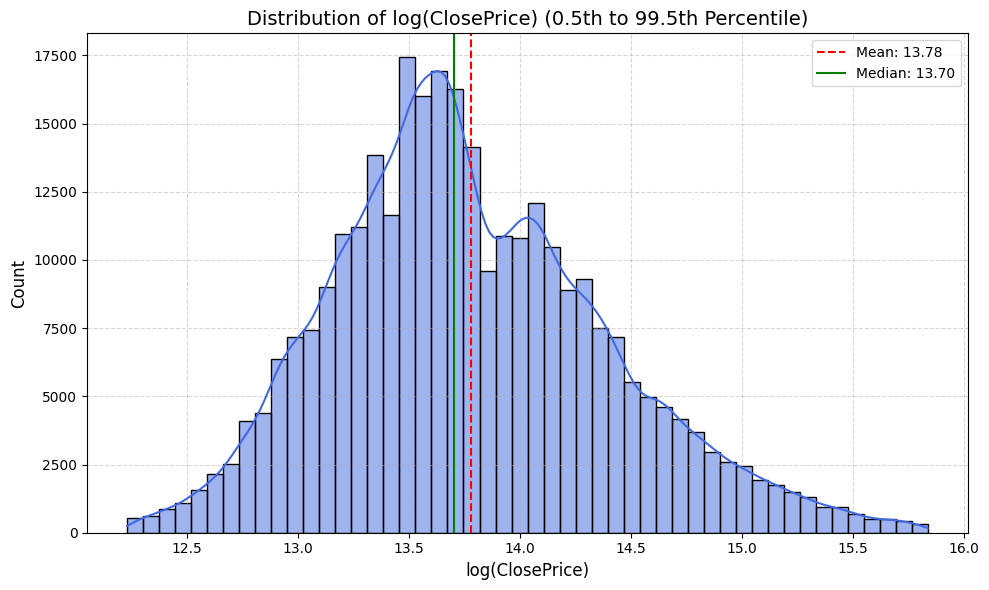

In [280]:
# Calculate cutoffs
lower_pct_val = np.percentile(df_clean['log_ClosePrice'], 0.5)
upper_pct_val = np.percentile(df_clean['log_ClosePrice'], 99.5)

# Filter
trimmed_log_prices = df_clean['log_ClosePrice'][(df_clean['log_ClosePrice'] >= lower_pct_val) & (df_clean['log_ClosePrice'] <= upper_pct_val)]

# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(trimmed_log_prices, kde=True, bins=50, color='royalblue')
plt.axvline(trimmed_log_prices.mean(), color='red', linestyle='--', label=f'Mean: {trimmed_log_prices.mean():.2f}')
plt.axvline(trimmed_log_prices.median(), color='green', linestyle='-', label=f'Median: {trimmed_log_prices.median():.2f}')
plt.title('Distribution of log(ClosePrice) (0.5th to 99.5th Percentile)', fontsize=14)
plt.xlabel('log(ClosePrice)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### `LivingArea`

In [281]:
df_clean['log_LivingArea'] = np.log1p(df_clean['LivingArea'])

### `LotSizeSquareFeet`

In [282]:
df_clean['log_LotSizeSquareFeet'] = np.log1p(df_clean['LotSizeSquareFeet'])

### `BuildingAreaTotal`

In [283]:
df_clean['log_BuildingAreaTotal'] = np.log1p(df_clean['BuildingAreaTotal'])

# Missing Proportions

In [284]:
# Columns with 100% missing data

n_rows = len(df_clean)
missing_count = df_clean.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': (missing_count / n_rows * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

cols_all_missing = missing_count[missing_count == n_rows].index.tolist()
cols_all_missing

['FireplacesTotal',
 'AboveGradeFinishedArea',
 'TaxAnnualAmount',
 'TaxYear',
 'ElementarySchoolDistrict',
 'BusinessType',
 'CoveredSpaces',
 'MiddleOrJuniorSchoolDistrict']

In [285]:
df_clean = df_clean.drop(columns=cols_all_missing)
print(f"Dropped {len(cols_all_missing)} fully empty columns. New shape: {df_clean.shape}")

pd.reset_option('display.float_format')

missing_df[(missing_df['Missing Count'] / n_rows > 0.50) & (missing_df['Missing Count'] < n_rows)]

Dropped 8 fully empty columns. New shape: (307722, 80)


,Missing Count,Missing Percentage (%)
WaterfrontYN,307591,99.96
BelowGradeFinishedArea,305840,99.39
BasementYN,300373,97.61
BuilderName,293321,95.32
LotSizeDimensions,289042,93.93
log_BuildingAreaTotal,288364,93.71
BuildingAreaTotal,288364,93.71
CoBuyerAgentFirstName,280131,91.03
OriginatingSystemName,274922,89.34
OriginatingSystemSubName,274922,89.34


# Imputations

- **Imputed Missing Values with `False`:**
  - `ViewYN`
  - `WaterfrontYN`
  - `PoolPrivateYN`
  - `FireplaceYN`
  - `NewConstructionYN`
- **Imputed Missing HOA Details**
  - `AssociationFeeFrequency` with `'None'`
  - `AssociationFee` with `0.0`

- **Imputed Numeric Values with Medians**

- **Imputed Categorical with Modes**

In [287]:
boolean_cols = ['ViewYN', 'WaterfrontYN', 'PoolPrivateYN', 'FireplaceYN']
for col in boolean_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(False).astype(bool)

pd.set_option('future.no_silent_downcasting', True)

# Impute missing values for NewConstructionYN with False
df_clean['NewConstructionYN'] = df_clean['NewConstructionYN'].fillna(False).astype(bool)

# Impute missing values for AssociationFeeFrequency with 'None'
df_clean['AssociationFeeFrequency'] = df_clean['AssociationFeeFrequency'].fillna('None')

# Impute missing values for AssociationFee with 0.0
df_clean['AssociationFee'] = df_clean['AssociationFee'].fillna(0.0)

# Numeric columns with median
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical/boolean with the mode
cat_bool_cols = df_clean.select_dtypes(exclude=[np.number]).columns
for col in cat_bool_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Dropping Columns

To build a robust and generalizable model that works for both on-market and off-market properties, I removed specific classes of columns like:

1. **Target Leakage**: `ListPrice`, `OriginalListPrice`, `DaysOnMarket`, and `ContractStatusChangeDate` exist only because a sale process is happening or has completed. Keeping them would be explicit data leakage.
2. **Unique Keys and System IDs**: `ListingKey`, `ListingKeyNumeric`, and `ListingId` do not represent physical property features.

In [288]:
# leakage columns to remove
columns_to_remove = [
    'ListPrice',
    'OriginalListPrice',
    'DaysOnMarket',
    'PurchaseContractDate',
    'ListingContractDate',
    'BuyerOfficeName',
    'BuyerAgentMlsId',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',
    'BuyerOfficeAOR',
    'CoBuyerAgentFirstName',
    'BuyerAgentAOR',
    'ListingKey',
    'ListAgentEmail',
    'ListAgentFirstName',
    'ListAgentLastName',
    'PropertyType',
    'CoListAgentFirstName',
    'CoListAgentLastName',
    'ListingKeyNumeric',
    'MlsStatus',
    'PropertySubType',
    'ListingId',
    'ContractStatusChangeDate',
    'StateOrProvince',
    'Levels',
    'OriginatingSystemName',
    'ListAgentFullName'
]

# Drop those columns
df_clean_leakage = df_clean.drop(columns=columns_to_remove)

print(f"Removed {len(columns_to_remove)} columns: {columns_to_remove}")
print(f"New DataFrame shape: {df_clean_leakage.shape}")

Removed 28 columns: ['ListPrice', 'OriginalListPrice', 'DaysOnMarket', 'PurchaseContractDate', 'ListingContractDate', 'BuyerOfficeName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerOfficeAOR', 'CoBuyerAgentFirstName', 'BuyerAgentAOR', 'ListingKey', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'PropertyType', 'CoListAgentFirstName', 'CoListAgentLastName', 'ListingKeyNumeric', 'MlsStatus', 'PropertySubType', 'ListingId', 'ContractStatusChangeDate', 'StateOrProvince', 'Levels', 'OriginatingSystemName', 'ListAgentFullName']
New DataFrame shape: (307722, 52)


### *80 down to 52 columns*

# Correlation with Target Variable

In [289]:
target = 'ClosePrice'
features = [col for col in df_clean_leakage.columns if col != target]

categorical_results = []
numerical_results = []

for col in features:
    temp = df_clean_leakage[[col, target]].dropna()
    if len(temp) < 10:
        continue

    col_series = temp[col]
    cardinality = df_clean_leakage[col].nunique()

    # Binary check comes first so 0/1 numeric flags are treated as categorical
    if col_series.nunique() == 2 or col_series.dtype == 'bool':
        if pd.api.types.is_numeric_dtype(col_series) and col_series.dtype != 'bool':
            binary_series = col_series.astype(float)
        else:
            binary_series = col_series.astype(str).str.lower().map(
                {'true': 1, '1': 1, '1.0': 1, 'false': 0, '0': 0, '0.0': 0}
            )
        binary_temp = pd.DataFrame({col: binary_series, target: temp[target]}).dropna()
        if len(binary_temp) > 10 and binary_temp[col].nunique() == 2:
            corr_coef, p_val = stats.pointbiserialr(binary_temp[col], binary_temp[target])
            categorical_results.append({
                'Feature': col,
                'Type': 'Binary',
                'Correlation/Strength': corr_coef,
                'P-value': p_val,
                'Method': 'Point-Biserial',
                'Cardinality': cardinality
            })

    elif pd.api.types.is_numeric_dtype(col_series):
        corr_coef, p_val = stats.pearsonr(col_series, temp[target])
        numerical_results.append({
            'Feature': col,
            'Type': 'Numeric',
            'Correlation/Strength': corr_coef,
            'P-value': p_val,
            'Method': 'Pearson r'
        })

    else:
        # Multi-class categorical: Correlation Ratio (Eta) = sqrt(SS_between / SS_total)
        groups = [group[target].values for _, group in temp.groupby(col)]
        if len(groups) > 1:
            f_val, p_val = stats.f_oneway(*groups)
            grand_mean = temp[target].mean()
            ss_total = np.sum((temp[target] - grand_mean) ** 2)
            ss_between = np.sum([len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups])
            eta = np.sqrt(ss_between / ss_total) if ss_total > 0 else 0
            categorical_results.append({
                'Feature': col,
                'Type': 'Categorical',
                'Correlation/Strength': eta,
                'P-value': p_val,
                'Method': 'Correlation Ratio (Eta)',
                'Cardinality': cardinality
            })

# Categorical (including binary), sorted by cardinality ascending
categorical_corr_df = (
    pd.DataFrame(categorical_results)
    .sort_values(by='Cardinality', ascending=True)
    .reset_index(drop=True)
)

# Numerical, sorted by correlation descending, no cardinality column
numerical_corr_df = (
    pd.DataFrame(numerical_results)
    .sort_values(by='Correlation/Strength', ascending=False)
    .reset_index(drop=True)
)

In [290]:
categorical_corr_df.head(15)


,Feature,Type,Correlation/Strength,P-value,Method,Cardinality
0,ViewYN,Binary,0.059175,9.783667e-237,Point-Biserial,2
1,WaterfrontYN,Binary,0.023296,3.265280e-38,Point-Biserial,2
2,PoolPrivateYN,Binary,0.124553,0.000000e+00,Point-Biserial,2
3,AttachedGarageYN,Binary,0.013489,7.270739e-14,Point-Biserial,2
4,latfilled,Binary,0.040125,7.702229e-110,Point-Biserial,2
5,NewConstructionYN,Binary,-0.019414,4.760984e-27,Point-Biserial,2
6,FireplaceYN,Binary,0.196616,0.000000e+00,Point-Biserial,2
7,Stories,Binary,0.113370,0.000000e+00,Point-Biserial,2
8,lonfilled,Binary,0.040125,7.702229e-110,Point-Biserial,2
9,BuyerAgencyCompensationType,Categorical,0.003123,2.230761e-01,Correlation Ratio (Eta),3


In [291]:
numerical_corr_df.head(10)

,Feature,Type,Correlation/Strength,P-value,Method
0,log_ClosePrice,Numeric,0.836943,0.000000e+00,Pearson r
1,LivingArea,Numeric,0.637813,0.000000e+00,Pearson r
2,BathroomsTotalInteger,Numeric,0.578867,0.000000e+00,Pearson r
3,log_LivingArea,Numeric,0.535855,0.000000e+00,Pearson r
4,BuildingAreaTotal,Numeric,0.406591,0.000000e+00,Pearson r
5,BedroomsTotal,Numeric,0.349028,0.000000e+00,Pearson r
6,log_BuildingAreaTotal,Numeric,0.333344,0.000000e+00,Pearson r
7,AssociationFee,Numeric,0.160835,0.000000e+00,Pearson r
8,log_LotSizeSquareFeet,Numeric,0.130476,0.000000e+00,Pearson r
9,GarageSpaces,Numeric,0.046418,2.308306e-146,Pearson r


# Initial Feature Selection without Feature Engineering

In [294]:
# Initial feature selection for my design matrix WITH target variable AND CloseDate
selected_features = [
    'log_ClosePrice',
    'CloseDate',
    'ViewYN',
    'WaterfrontYN',
    'PoolPrivateYN',
    'Stories',
    'FireplaceYN',
    'AssociationFeeFrequency',
    'log_LivingArea',
    'BathroomsTotalInteger',
    'log_BuildingAreaTotal',
    'BedroomsTotal',
    'AssociationFee',
    'log_LotSizeSquareFeet',
    'GarageSpaces'
]

X = df_clean_leakage[selected_features]
print(f"Design matrix X shape before one-hot Encoding: {X.shape}")
display(X.head())

Design matrix X shape before one-hot Encoding: (307722, 15)


,log_ClosePrice,CloseDate,ViewYN,WaterfrontYN,PoolPrivateYN,Stories,FireplaceYN,AssociationFeeFrequency,log_LivingArea,BathroomsTotalInteger,log_BuildingAreaTotal,BedroomsTotal,AssociationFee,log_LotSizeSquareFeet,GarageSpaces
0,13.610943,2024-01-05,False,False,False,2.0,False,None,7.588324,4.0,7.601402,4.0,0.0,8.887791,2.0
1,13.604790,2024-01-05,False,False,False,2.0,False,None,7.588324,4.0,7.601402,4.0,0.0,8.887791,2.0
2,14.557448,2024-01-02,True,False,False,2.0,True,None,8.226038,4.0,7.601402,4.0,0.0,9.325453,3.0
3,14.665661,2024-01-31,True,False,False,1.0,True,None,7.800982,3.0,7.601402,4.0,0.0,9.072571,3.0
4,13.873779,2024-01-16,True,False,False,1.0,True,None,7.559038,3.0,7.559038,3.0,0.0,9.475010,2.0


#### One-Hot Encoding and Converting Booleans to 0/1

In [295]:
# OHE
X = pd.get_dummies(X, columns=['AssociationFeeFrequency'], drop_first=True)

# boolean to integer 0/1
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

print("\nDesign matrix shape after one-hot encoding:", X.shape)
X.head()


Design matrix shape after one-hot encoding: (307722, 18)


,log_ClosePrice,CloseDate,ViewYN,WaterfrontYN,PoolPrivateYN,Stories,FireplaceYN,log_LivingArea,BathroomsTotalInteger,log_BuildingAreaTotal,BedroomsTotal,AssociationFee,log_LotSizeSquareFeet,GarageSpaces,AssociationFeeFrequency_Monthly,AssociationFeeFrequency_None,AssociationFeeFrequency_Quarterly,AssociationFeeFrequency_SemiAnnually
0,13.610943,2024-01-05,0,0,0,2.0,0,7.588324,4.0,7.601402,4.0,0.0,8.887791,2.0,0,1,0,0
1,13.604790,2024-01-05,0,0,0,2.0,0,7.588324,4.0,7.601402,4.0,0.0,8.887791,2.0,0,1,0,0
2,14.557448,2024-01-02,1,0,0,2.0,1,8.226038,4.0,7.601402,4.0,0.0,9.325453,3.0,0,1,0,0
3,14.665661,2024-01-31,1,0,0,1.0,1,7.800982,3.0,7.601402,4.0,0.0,9.072571,3.0,0,1,0,0
4,13.873779,2024-01-16,1,0,0,1.0,1,7.559038,3.0,7.559038,3.0,0.0,9.475010,2.0,0,1,0,0


# Train/Test Split

### **Chronological Train/Test Split & Cross-Validation Strategy**

* **Test Set:** April 2026 Data Only
* **Training/Validation Set:** The remaining (earlier) data serves as our development set.
* **5-Fold Cross-Validation:** The training set is split into 5 chronological folds to preserve temporal integrity during hyperparameter tuning and model optimization.

In [296]:
from sklearn.model_selection import TimeSeriesSplit

test_start, test_end = pd.Timestamp('2026-04-01'), pd.Timestamp('2026-05-01')
train_df = X[X['CloseDate'] < test_start].sort_values('CloseDate').reset_index(drop=True)
test_df = X[(X['CloseDate'] >= test_start) & (X['CloseDate'] < test_end)]

print(f"Train: {len(train_df):,} rows ({train_df['CloseDate'].min().date()} to {train_df['CloseDate'].max().date()})")
print(f"Test:  {len(test_df):,} rows ({test_df['CloseDate'].min().date()} to {test_df['CloseDate'].max().date()})")


drop_cols = ['log_ClosePrice', 'CloseDate']
X_train, y_train = train_df.drop(columns=drop_cols), train_df['log_ClosePrice']
X_test, y_test = test_df.drop(columns=drop_cols), test_df['log_ClosePrice']


# Time-ordered 5-fold CV!!!
tscv = TimeSeriesSplit(n_splits=5)
for i, (tr, va) in enumerate(tscv.split(X_train), start=1):
    print(f"Fold {i}: train {len(tr):,} rows "
          f"({train_df['CloseDate'].iloc[tr[0]].date()} to {train_df['CloseDate'].iloc[tr[-1]].date()}), "
          f"validate {len(va):,} rows "
          f"({train_df['CloseDate'].iloc[va[0]].date()} to {train_df['CloseDate'].iloc[va[-1]].date()})")

Train: 295,317 rows (2024-01-01 to 2026-03-31)
Test:  12,405 rows (2026-04-01 to 2026-04-30)
Fold 1: train 49,222 rows (2024-01-01 to 2024-05-17), validate 49,219 rows (2024-05-17 to 2024-09-13)
Fold 2: train 98,441 rows (2024-01-01 to 2024-09-13), validate 49,219 rows (2024-09-13 to 2025-02-06)
Fold 3: train 147,660 rows (2024-01-01 to 2025-02-06), validate 49,219 rows (2025-02-06 to 2025-06-20)
Fold 4: train 196,879 rows (2024-01-01 to 2025-06-20), validate 49,219 rows (2025-06-20 to 2025-10-28)
Fold 5: train 246,098 rows (2024-01-01 to 2025-10-28), validate 49,219 rows (2025-10-28 to 2026-03-31)


### Fold 1 of Design Matrix and Target Vector

In [303]:
# Get the index splits for Fold 1
train_idx, val_idx = next(tscv.split(X_train))

# Extract the subsets for Fold 1
X_fold1_train = X_train.iloc[train_idx]
y_fold1_train = y_train.iloc[train_idx]

print("--- Fold 1 X (Features) Head ---")
display(X_fold1_train.head())

print("\n--- Fold 1 y (Target) Head ---")
display(y_fold1_train.head())

--- Fold 1 X (Features) Head ---


,ViewYN,WaterfrontYN,PoolPrivateYN,Stories,FireplaceYN,log_LivingArea,BathroomsTotalInteger,log_BuildingAreaTotal,BedroomsTotal,AssociationFee,log_LotSizeSquareFeet,GarageSpaces,AssociationFeeFrequency_Monthly,AssociationFeeFrequency_None,AssociationFeeFrequency_Quarterly,AssociationFeeFrequency_SemiAnnually
0,0,0,0,1.0,0,6.842683,2.0,7.601402,3.0,0.0,8.836810,2.0,0,1,0,0
1,0,0,0,1.0,1,7.109062,2.0,7.601402,3.0,0.0,8.949105,2.0,0,1,0,0
2,0,0,0,2.0,0,7.893199,3.0,7.601402,4.0,0.0,8.894807,3.0,0,1,0,0
3,0,0,0,2.0,1,7.571988,3.0,7.601402,4.0,140.0,8.444622,2.0,1,0,0,0
4,1,0,1,1.0,0,7.244942,1.0,7.601402,3.0,0.0,8.849371,2.0,0,1,0,0



--- Fold 1 y (Target) Head ---


,log_ClosePrice
0,12.821258
1,13.190022
2,13.208541
3,13.726679
4,13.226723
